# Gradient Descent: correctness checks, tables, and plots

This notebook implements and evaluates three algorithms from `MAIN.md`:
1) Constant-step gradient descent  
2) Gradient descent with Armijo backtracking  
3) Steepest Descent with exact line search (for quadratics)

We test on:

### a strongly convex quadratic $ f(x)=\tfrac12 x^\top A x - b^\top x $ (with known minimizer)

We use

$$
f_{\mathrm{quad}}(x)=\tfrac12\,x^\top A x - b^\top x,
\qquad
A=\begin{bmatrix}3&1\\1&2\end{bmatrix},\quad
b=\begin{bmatrix}1\\1\end{bmatrix}.
$$

- **Properties.** $A$ is symmetric positive definite (SPD), so $f$ is strongly convex.  
  The gradient and Hessian are
  $$
  \nabla f(x)=Ax-b, \qquad \nabla^2 f(x)=A.
  $$
  The eigenvalues of $A$ are
  $ \lambda_{\min}=\frac{5-\sqrt{5}}{2}\approx 1.382 $ and
  $ \lambda_{\max}=\frac{5+\sqrt{5}}{2}\approx 3.618 $.
  Thus $m=\lambda_{\min}$, $L=\lambda_{\max}$, and the condition number
  $ \kappa=L/m\approx 2.618 $.

- **Known solution.** The unique minimizer solves $Ax=b$:
  $$
  x_\star=A^{-1}b=\begin{bmatrix}0.2\\0.4\end{bmatrix},
  \qquad
  f_\star=f(x_\star)=-\tfrac12\,b^\top A^{-1}b=-0.3.
  $$
  Having $(x_\star,f_\star)$ lets us report exact errors $|f_k-f_\star|$ and $\|x_k-x_\star\|$.

---

### the 2D Rosenbrock function

We consider
$$
f(u,v)=(1-u)^2+100\,(v-u^2)^2.
$$

**Unique global minimum at $(1,1)$ and $f_\star=0$.**  
The function is a sum of squares, hence $f(u,v)\ge 0$ for all $(u,v)$.
Equality $f(u,v)=0$ requires both squares to be zero:
$$
(1-u)^2=0 \Rightarrow u=1,\qquad (v-u^2)^2=0 \Rightarrow v=u^2=1.
$$
Therefore the only point with value $0$ is $(u,v)=(1,1)$.

**Nonconvex overall.**  
Convexity would require the Hessian to be PSD everywhere, but
$$
\nabla^2 f(u,v)=
\begin{bmatrix}
2-400\,(v-3u^2) & -400u\\
-400u & 200
\end{bmatrix}
$$
is indefinite at many points (e.g., at $(0,1)$ it is
$\begin{bmatrix}-398&0\\0&200\end{bmatrix}$).

**“Narrow, curved valley.”**  
Near $(1,1)$,
$$
\nabla^2 f(1,1)=\begin{bmatrix}802&-400\\-400&200\end{bmatrix},
$$
whose eigenvalues are about $1001.6$ and $0.4$, giving $\kappa\approx 2500$.

**Why constant-step GD is sensitive to $\lambda$.**  
Stability near $(1,1)$ needs $\lambda<2/L$ with $L\approx 1002$, i.e. $\lambda\lesssim 0.002$.

**Why Armijo backtracking is more robust.**  
Backtracking chooses $\lambda_k$ to satisfy
$$
f(x_k-\lambda_k\nabla f(x_k))
\le
f(x_k) - c\,\lambda_k\|\nabla f(x_k)\|^2,
$$
shrinking steps in steep regions and enlarging them in flat ones.


In [15]:

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable, Dict, List
import pandas as pd

%matplotlib inline

@dataclass
class Hist:
    xs: List[np.ndarray]
    fs: List[float]
    grads: List[np.ndarray]
    lams: List[float]

def norm2(x: np.ndarray) -> float:
    return float(np.linalg.norm(x))

def run_fixed_step_gd(f: Callable[[np.ndarray], float],
                      grad: Callable[[np.ndarray], np.ndarray],
                      x0: np.ndarray,
                      lam: float,
                      maxit: int = 10_000,
                      tol: float = 1e-8) -> Hist:
    xs = [x0.copy()]
    fs = [f(x0)]
    grads = [grad(x0)]
    lams = []
    x = x0.copy()
    for k in range(maxit):
        g = grad(x)
        step = lam * g
        x_new = x - step
        xs.append(x_new.copy())
        fs.append(f(x_new))
        grads.append(grad(x_new))
        lams.append(lam)
        if norm2(x_new - x) <= tol or abs(fs[-1] - fs[-2]) <= tol or norm2(g) <= tol:
            break
        x = x_new
    return Hist(xs, fs, grads, lams)

def run_backtracking_armijo(f: Callable[[np.ndarray], float],
                            grad: Callable[[np.ndarray], np.ndarray],
                            x0: np.ndarray,
                            eps: float = 1e-4,
                            delta: float = 0.5,
                            t0: float = 1.0,
                            maxit: int = 10_000,
                            tol: float = 1e-8) -> Hist:
    xs = [x0.copy()]
    fs = [f(x0)]
    grads = [grad(x0)]
    lams = []
    x = x0.copy()
    for k in range(maxit):
        g = grad(x)
        fx = f(x)
        t = t0
        # Armijo: f(x - t g) <= f(x) - eps * t * ||g||^2
        while f(x - t * g) > fx - eps * t * (norm2(g) ** 2):
            t *= delta
            if t < 1e-16:
                break
        x_new = x - t * g
        xs.append(x_new.copy())
        fs.append(f(x_new))
        grads.append(grad(x_new))
        lams.append(t)
        if norm2(x_new - x) <= tol or abs(fs[-1] - fs[-2]) <= tol or norm2(g) <= tol:
            break
        x = x_new
    return Hist(xs, fs, grads, lams)

def run_steepest_descent_exact_quadratic(A: np.ndarray,
                                         b: np.ndarray,
                                         x0: np.ndarray,
                                         maxit: int = 10_000,
                                         tol: float = 1e-8) -> Hist:
    # f(x) = 0.5 x^T A x - b^T x ; grad = A x - b
    def f(x): return 0.5 * float(x.T @ A @ x) - float(b.T @ x)
    def g(x): return A @ x - b
    
    xs = [x0.copy()]
    fs = [f(x0)]
    grads = [g(x0)]
    lams = []
    x = x0.copy()
    for k in range(maxit):
        grad_k = g(x)
        if norm2(grad_k) <= tol:
            break
        # Exact step: alpha = (g^T g) / (g^T A g)
        alpha = float(grad_k.T @ grad_k) / float(grad_k.T @ A @ grad_k)
        x_new = x - alpha * grad_k
        xs.append(x_new.copy())
        fs.append(f(x_new))
        grads.append(g(x_new))
        lams.append(alpha)
        if norm2(x_new - x) <= tol or abs(fs[-1] - fs[-2]) <= tol:
            break
        x = x_new
    return Hist(xs, fs, grads, lams)


In [16]:

# Strongly convex quadratic
A = np.array([[3.0, 1.0],
              [1.0, 2.0]])
b = np.array([1.0, 1.0])

Ainv = np.linalg.inv(A)
xstar_quad = Ainv @ b

def f_quad(x: np.ndarray) -> float:
    return 0.5 * float(x.T @ A @ x) - float(b.T @ x)

def g_quad(x: np.ndarray) -> np.ndarray:
    return A @ x - b

fstar_quad = f_quad(xstar_quad)

# Rosenbrock (2D)
def f_rosen(x: np.ndarray) -> float:
    u, v = x[0], x[1]
    return (1 - u) ** 2 + 100.0 * (v - u ** 2) ** 2

def g_rosen(x: np.ndarray) -> np.ndarray:
    u, v = x[0], x[1]
    dfdu = -2 * (1 - u) - 400 * u * (v - u ** 2)
    dfdv = 200 * (v - u ** 2)
    return np.array([dfdu, dfdv])

xstar_rosen = np.array([1.0, 1.0])
fstar_rosen = 0.0


In [11]:

# Starting points
x0_quad = np.array([2.5, -1.0])
x0_rosen = np.array([-1.2, 1.0])

# Fixed-step lambdas (theory: 0 < lambda < 2/L, L=max eigenvalue of A)
L_quad = max(np.linalg.eigvals(A)).real
lambda_grid = np.linspace(0.05, 1.9 / L_quad, 10)

rows = []
fixed_histories = {}
for lam in lambda_grid:
    hist = run_fixed_step_gd(f_quad, g_quad, x0_quad, lam=lam, maxit=10000, tol=1e-10)
    fixed_histories[lam] = hist
    final_f = hist.fs[-1]
    acc = abs(final_f - fstar_quad)
    rows.append({
        "Step value λ": lam,
        "Achieved accuracy |f_k - f*|": acc,
        "Number of iterations": len(hist.fs) - 1
    })

df_fixed = pd.DataFrame(rows).sort_values("Step value λ").reset_index(drop=True)
df_fixed


,Step value λ,Achieved accuracy |f_k - f*|,Number of iterations
0,0.050000,5.936515e-10,158
1,0.102794,2.251365e-10,77
2,0.155588,1.218742e-10,50
3,0.208382,9.538448e-11,36
4,0.261176,5.132955e-11,28
5,0.313971,1.710515e-11,23
6,0.366765,8.568701e-12,19
7,0.419559,1.007178e-11,20
8,0.472353,9.446421e-11,35
9,0.525147,3.522745e-10,108


In [17]:
# ---------- Armijo backtracking: grid over (eps, delta) ----------
armijo_grid = []
for eps in [1e-1, 1e-2, 1e-3, 1e-4]:
    for delta in [0.1, 0.3, 0.5, 0.7, 0.9]:
        armijo_grid.append({"eps": eps, "delta": delta, "t0": 1.0})

rows_armijo = []
armijo_histories = {}

for cfg in armijo_grid:
    hist = run_backtracking_armijo(
        f_quad, g_quad, x0_quad,
        eps=cfg["eps"], delta=cfg["delta"], t0=cfg["t0"],
        maxit=10_000, tol=1e-10
    )
    armijo_histories[(cfg["eps"], cfg["delta"])] = hist
    fs, lams = hist.fs, np.array(hist.lams) if hist.lams else np.array([0.0])
    acc = abs(fs[-1] - fstar_quad)
    # Считаем, сколько раз было бэктрекингов: когда t уменьшался по сравнению с предыдущей попыткой в этом шаге
    # (в нашей реализации одна попытка на шаг, поэтому приблизительно считаем "сколько раз t < t0")
    backtracks = int(np.sum(lams < cfg["t0"]))
    rows_armijo.append({
        "Armijo eps": cfg["eps"],
        "Shrink delta": cfg["delta"],
        "t0": cfg["t0"],
        "λ̄ (mean)": float(np.mean(lams)),
        "λ_med (median)": float(np.median(lams)),
        "λ_min": float(np.min(lams)),
        "λ_max": float(np.max(lams)),
        "Backtracks (count)": backtracks,
        "Achieved accuracy |f_k - f*|": acc,
        "Number of iterations": len(fs) - 1,
    })

df_armijo = (pd.DataFrame(rows_armijo)
             .sort_values(["Armijo eps", "Shrink delta"])
             .reset_index(drop=True))
df_armijo


,Armijo eps,Shrink delta,t0,λ̄ (mean),λ_med (median),λ_min,λ_max,Backtracks (count),Achieved accuracy |f_k - f*|,Number of iterations
0,0.0001,0.1,1.0,0.212500,0.100000,0.100000,1.00000,42,1.555932e-10,48
1,0.0001,0.3,1.0,0.650000,0.650000,0.300000,1.00000,9,1.303707e-11,18
2,0.0001,0.5,1.0,0.500000,0.500000,0.500000,0.50000,56,1.323596e-10,56
3,0.0001,0.7,1.0,0.494286,0.490000,0.490000,0.70000,49,1.142327e-10,49
4,0.0001,0.9,1.0,0.532307,0.531441,0.531441,0.65610,144,5.287961e-10,144
5,0.0010,0.1,1.0,0.212500,0.100000,0.100000,1.00000,42,1.555932e-10,48
6,0.0010,0.3,1.0,0.650000,0.650000,0.300000,1.00000,9,1.303707e-11,18
7,0.0010,0.5,1.0,0.500000,0.500000,0.500000,0.50000,56,1.323596e-10,56
8,0.0010,0.7,1.0,0.494286,0.490000,0.490000,0.70000,49,1.142327e-10,49
9,0.0010,0.9,1.0,0.532307,0.531441,0.531441,0.65610,144,5.287961e-10,144


In [18]:
# ---------- Steepest Descent (exact line search on quadratic): vary starting points ----------
starts = [
    np.array([2.5, -1.0]),     # твой исходный
    np.array([-2.0, 2.0]),
    np.array([10.0, -10.0]),
    np.array([0.0, 0.0]),
    np.array([1.5, 1.5]),
]

rows_exact = []
exact_histories = {}

for x0 in starts:
    hist = run_steepest_descent_exact_quadratic(A, b, x0, maxit=10_000, tol=1e-10)
    fs, lams = hist.fs, np.array(hist.lams) if hist.lams else np.array([0.0])
    rows_exact.append({
        "x0": x0,
        "λ̄ (mean)": float(np.mean(lams)),
        "λ_med (median)": float(np.median(lams)),
        "λ_min": float(np.min(lams)),
        "λ_max": float(np.max(lams)),
        "Achieved accuracy |f_k - f*|": abs(fs[-1] - fstar_quad),
        "Number of iterations": len(fs) - 1,
    })
    exact_histories[tuple(x0)] = hist

df_exact = pd.DataFrame(rows_exact)
df_exact


,x0,λ̄ (mean),λ_med (median),λ_min,λ_max,Achieved accuracy |f_k - f*|,Number of iterations
0,"[2.5, -1.0]",0.406307,0.406307,0.355685,0.456929,1.542572e-11,16
1,"[-2.0, 2.0]",0.399654,0.388060,0.388060,0.412698,7.741252e-12,17
2,"[10.0, -10.0]",0.426057,0.426057,0.320692,0.531422,7.866541e-12,16
3,"[0.0, 0.0]",0.455026,0.285714,0.285714,0.666667,3.776979e-13,9
4,"[1.5, 1.5]",0.498379,0.498379,0.276952,0.719807,5.939693e-15,6


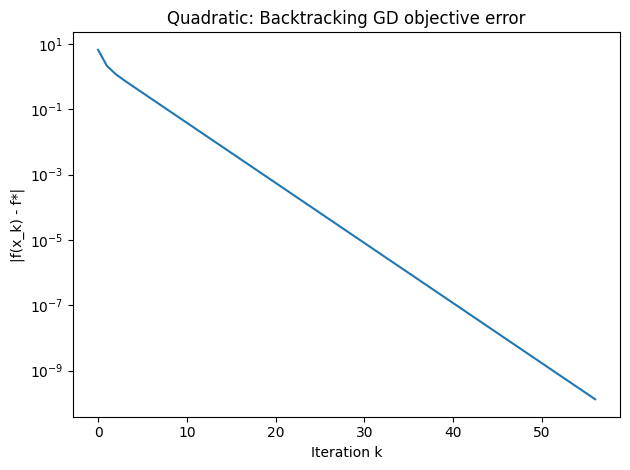

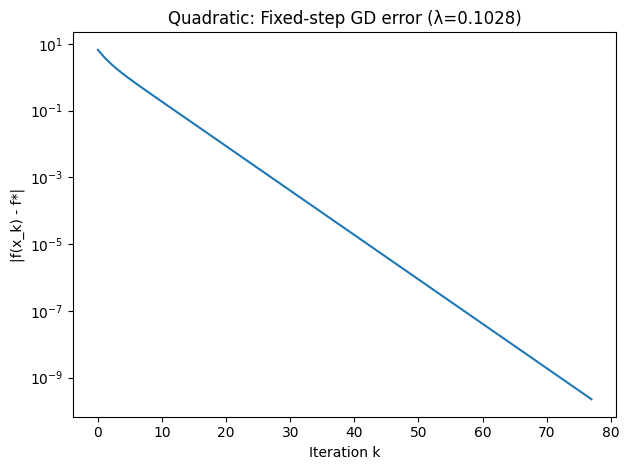

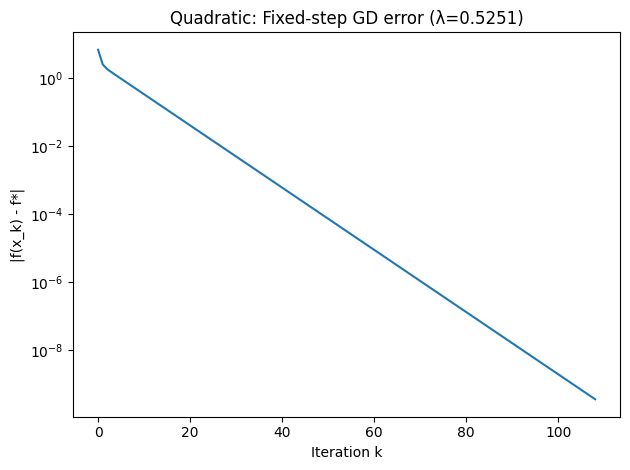

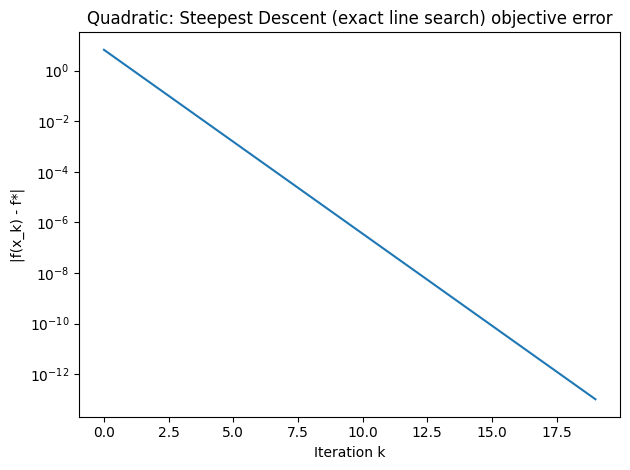

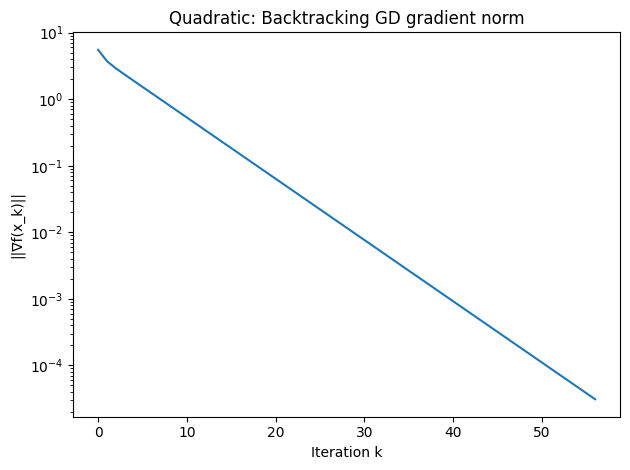

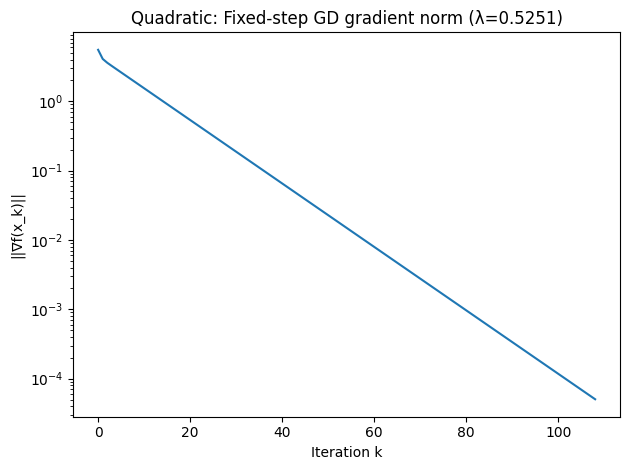

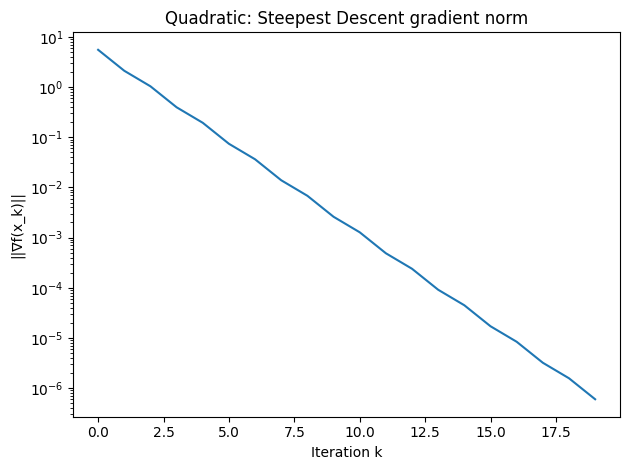

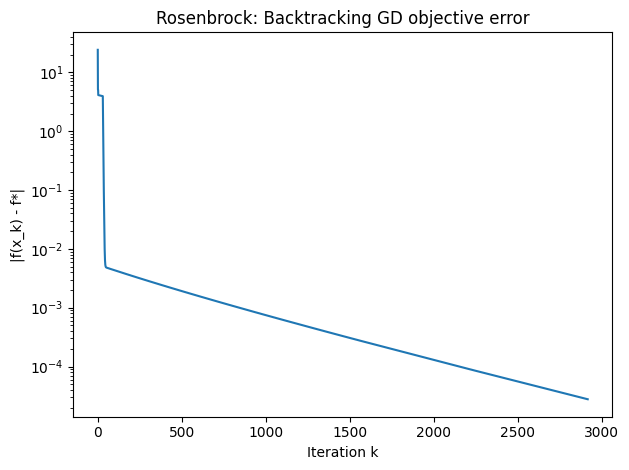

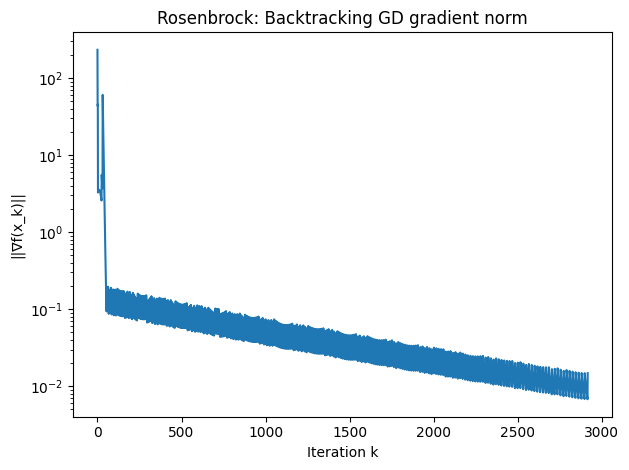

In [19]:

def plot_error_vs_iterations(hist: Hist, fstar: float, title: str):
    errs = [abs(f - fstar) for f in hist.fs]
    plt.figure()
    plt.semilogy(range(len(errs)), errs)
    plt.xlabel("Iteration k")
    plt.ylabel("|f(x_k) - f*|")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_gradnorm_vs_iterations(hist: Hist, title: str):
    gnorms = [norm2(g) for g in hist.grads]
    plt.figure()
    plt.semilogy(range(len(gnorms)), gnorms)
    plt.xlabel("Iteration k")
    plt.ylabel("||∇f(x_k)||")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Backtracking on quadratic and Rosenbrock
bt_quad = run_backtracking_armijo(f_quad, g_quad, x0_quad, eps=1e-4, delta=0.5, t0=1.0, maxit=10000, tol=1e-10)
bt_rosen = run_backtracking_armijo(f_rosen, g_rosen, x0_rosen, eps=1e-4, delta=0.5, t0=1.0, maxit=100000, tol=1e-10)

# Steepest Descent with exact line search (quadratic)
sd_quad = run_steepest_descent_exact_quadratic(A, b, x0_quad, maxit=10000, tol=1e-12)

# Error plots (quadratic)
plot_error_vs_iterations(bt_quad, fstar_quad, "Quadratic: Backtracking GD objective error")
lam_small = list(fixed_histories.keys())[1]
lam_large = list(fixed_histories.keys())[-1]
plot_error_vs_iterations(fixed_histories[lam_small], fstar_quad, f"Quadratic: Fixed-step GD error (λ={lam_small:.4f})")
plot_error_vs_iterations(fixed_histories[lam_large], fstar_quad, f"Quadratic: Fixed-step GD error (λ={lam_large:.4f})")
plot_error_vs_iterations(sd_quad, fstar_quad, "Quadratic: Steepest Descent (exact line search) objective error")

# Gradient norm plots (quadratic)
plot_gradnorm_vs_iterations(bt_quad, "Quadratic: Backtracking GD gradient norm")
plot_gradnorm_vs_iterations(fixed_histories[lam_large], f"Quadratic: Fixed-step GD gradient norm (λ={lam_large:.4f})")
plot_gradnorm_vs_iterations(sd_quad, "Quadratic: Steepest Descent gradient norm")

# Rosenbrock plots
plot_error_vs_iterations(bt_rosen, fstar_rosen, "Rosenbrock: Backtracking GD objective error")
plot_gradnorm_vs_iterations(bt_rosen, "Rosenbrock: Backtracking GD gradient norm")
